In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
%cd /content/drive/My Drive/

/content/drive/My Drive


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [7]:
data = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/Google Stock Prediction Using RNN and LSTM/Google_Stock_Price_Train.csv")

In [8]:
#information of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   object 
 5   Volume  1258 non-null   object 
dtypes: float64(3), object(3)
memory usage: 59.1+ KB


In [9]:
data.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [10]:
#dataset values(Max,min,std..)
data.describe()

,Open,High,Low
count,1258.000000,1258.000000,1258.000000
mean,533.709833,537.880223,529.007409
std,151.904442,153.008811,150.552807
min,279.120000,281.210000,277.220000
25%,404.115000,406.765000,401.765000
50%,537.470000,540.750000,532.990000
75%,654.922500,662.587500,644.800000
max,816.680000,816.680000,805.140000


In [14]:
# Assuming 'data' is your original DataFrame

# Before calculating the correlation, convert relevant columns to numeric if needed
for column in ['Open', 'High', 'Low', 'Close', 'Volume']:  # Add other numeric columns as needed
    # Check if the column type is object (string) before applying str.replace
    if data[column].dtype == object:
        data[column] = data[column].str.replace(',', '').astype(float)
    else:
        # If the column is already numeric, no need for conversion
        pass

# Now calculate the correlation, selecting only numeric columns
numeric_data = data.select_dtypes(include=np.number)
correlation_matrix = numeric_data.corr()

# Print or use the correlation_matrix as needed
print(correlation_matrix)

            Open      High       Low     Close    Volume
Open    1.000000  0.999692  0.999498  0.125832 -0.530506
High    0.999692  1.000000  0.999480  0.124351 -0.526936
Low     0.999498  0.999480  1.000000  0.129001 -0.538273
Close   0.125832  0.124351  0.129001  1.000000  0.192357
Volume -0.530506 -0.526936 -0.538273  0.192357  1.000000


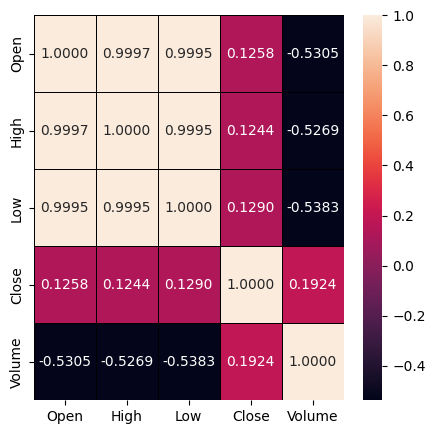

In [16]:
#visualization of correlation result with seaborn library heatmap
f,ax=plt.subplots(figsize=(5,5))
# Remove 'Date' column before calculating correlation
sns.heatmap(data.drop(columns=['Date']).corr(),annot=True,linewidths=0.5,linecolor="black",fmt=".4f",ax=ax)
plt.show()

In [18]:
#dataset columns areas
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [19]:
data_set=data.loc[:,["Open"]].values
data_set

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]])

In [20]:
train=data_set[:len(data_set)-50]
test=data_set[len(train):]
train.reshape(train.shape[0],1)
train.shape

(1208, 1)

In [21]:
# Assuming 'data_set' is your original data
train_size = int(len(data_set) * 0.8)  # Adjust the split ratio as needed
train = data_set[:train_size]
test = data_set[train_size:]

# Reshape train if necessary (should be done before scaling)
train = train.reshape(train.shape[0], 1)

# Now proceed with scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaler = scaler.fit_transform(train)

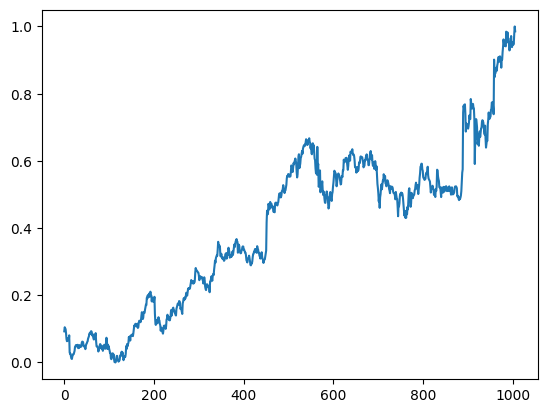

In [22]:
plt.plot(train_scaler)
plt.show()

In [23]:
X_train = []
Y_train = []
# Reducing timesteps to be less than the length of train_scaler
timesteps = 10  # or any value less than len(train_scaler)

for i in range(timesteps, len(train_scaler)):
    X_train.append(train_scaler[i - timesteps:i, 0])
    Y_train.append(train_scaler[i, 0])

X_train, Y_train = np.array(X_train), np.array(Y_train)

# reshape
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [24]:
X_train.shape

(996, 10, 1)

In [25]:
X_train

array([[[0.09272735],
        [0.10482833],
        [0.10193375],
        ...,
        [0.07097773],
        [0.0660127 ],
        [0.07174158]],

       [[0.10482833],
        [0.10193375],
        [0.09893865],
        ...,
        [0.0660127 ],
        [0.07174158],
        [0.06637453]],

       [[0.10193375],
        [0.09893865],
        [0.08627483],
        ...,
        [0.07174158],
        [0.06637453],
        [0.08076707]],

       ...,

       [[0.93002734],
        [0.95256091],
        [0.94653051],
        ...,
        [0.95350567],
        [0.94562595],
        [0.9524001 ]],

       [[0.95256091],
        [0.94653051],
        [0.97149634],
        ...,
        [0.94562595],
        [0.9524001 ],
        [0.9800796 ]],

       [[0.94653051],
        [0.97149634],
        [0.93951516],
        ...,
        [0.9524001 ],
        [0.9800796 ],
        [1.        ]]])

In [26]:
Y_train

array([6.63745276e-02, 8.07670660e-02, 3.02323712e-02, 2.57095763e-02,
       2.60311972e-02, 1.72067219e-02, 1.16587602e-02, 1.04526815e-02,
       1.77494573e-02, 2.26943797e-02, 2.46442068e-02, 2.45638016e-02,
       3.03730803e-02, 3.47149634e-02, 4.68762563e-02, 4.83637533e-02,
       5.17608748e-02, 4.76200048e-02, 5.02331752e-02, 5.12784434e-02,
       5.26654338e-02, 4.25343732e-02, 4.47053148e-02, 4.35997427e-02,
       5.17005709e-02, 4.67355472e-02, 4.70772694e-02, 4.63134196e-02,
       4.97306424e-02, 5.83340034e-02, 6.20125432e-02, 6.17512262e-02,
       6.01833240e-02, 4.77808153e-02, 4.87858808e-02, 4.97708451e-02,
       4.76803088e-02, 3.97201898e-02, 4.84843612e-02, 5.47358688e-02,
       5.63439736e-02, 6.06456541e-02, 6.28768996e-02, 7.06762081e-02,
       7.43748492e-02, 7.82745035e-02, 8.63753317e-02, 8.47873281e-02,
       8.68175605e-02, 9.18227868e-02, 9.32298786e-02, 9.15413685e-02,
       8.05459516e-02, 8.51893543e-02, 7.82141996e-02, 7.20028946e-02,
      

In [27]:
# Import Library
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Dropout

# Initialising the RNN
regressor = Sequential()

# Add the first RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50, activation = "tanh", return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Second RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50, activation = "tanh", return_sequences = True))
regressor.add(Dropout(0.2))

# Third RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50, activation = "tanh", return_sequences = True))
regressor.add(Dropout(0.2))

# Fourth RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50))
regressor.add(Dropout(0.2))

# Add the output layer
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(optimizer = "adam", loss = "mean_squared_error")

# Fitting the RNN to the training set
regressor.fit(X_train, Y_train, epochs = 100, batch_size = 32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.6781
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1990
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1483
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1293
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0852
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0838
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0650
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0609
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0531
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0456
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0453
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0364
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0322
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0307
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0249
E

PREDICTIONS AND VISUALISING RNN MODEL


In [28]:
inputs = data_set[len(data_set) - len(test) - timesteps:]
inputs = scaler.transform(inputs)

In [29]:
X_test = []
for i in range(timesteps, inputs.shape[0]):
    X_test.append(inputs[i - timesteps:i, 0])

X_test_rnn = np.array(X_test)
X_test_rnn = np.reshape(X_test_rnn, (X_test_rnn.shape[0], X_test_rnn.shape[1], 1))
predicted_stock_price = regressor.predict(X_test_rnn)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step


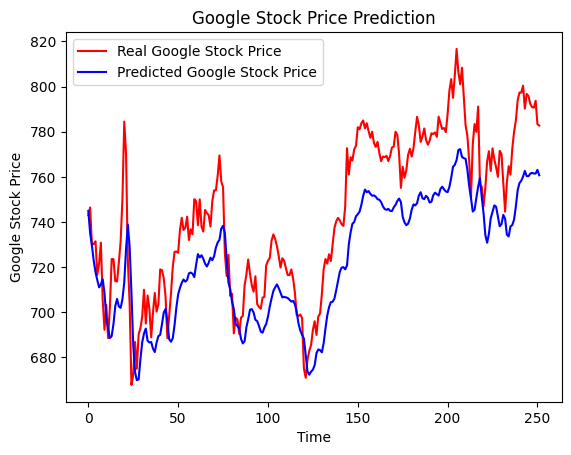

In [30]:
# visualising the results
plt.plot(test, color = "red", label = "Real Google Stock Price")
plt.plot(predicted_stock_price, color = "blue", label = "Predicted Google Stock Price")
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Google Stock Price")
plt.legend()
plt.show()

Long Short Term Memory(LSTM)

Create And Training LSTM Model

In [31]:
trainX = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))

In [32]:
# Import Library For LSTM Model
import math
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [33]:
model = Sequential()
model.add(LSTM(10, input_shape = (1, timesteps)))
model.add(Dense(1))
model.compile(loss = "mean_squared_error", optimizer = "adam")
model.fit(trainX, Y_train, epochs = 50, batch_size = 1)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0120
Epoch 2/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 8.6820e-04
Epoch 3/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 7.5595e-04
Epoch 4/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 6.2742e-04
Epoch 5/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 6.1194e-04
Epoch 6/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 7.0682e-04
Epoch 7/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5.7297e-04
Epoch 8/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.1008e-04
Epoch 9/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.4358e-04
Epoch 10/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5.0159e-04
Epoch 11/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.0987e-04
Epoch 12/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 5.0454e-04
Epoch 13/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 4.6620e-04
Epoch 14/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.2195e-04
Epoch 15/50
996/

Predictions And Visualising LSTM Model

ValueError: File not found: filepath=my_model.keras. Please ensure the file is an accessible `.keras` zip file.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


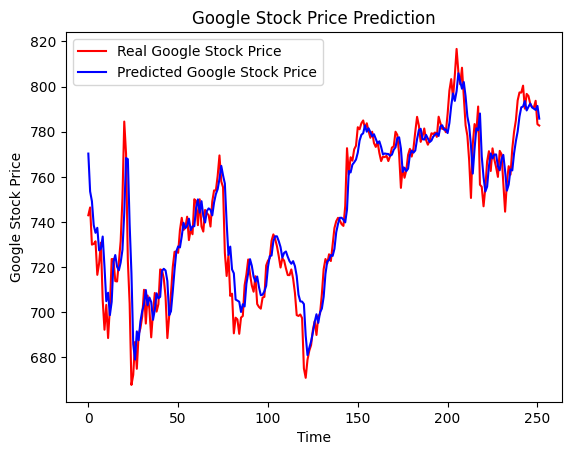

In [35]:
# visualising the results
plt.plot(test, color = "red", label = "Real Google Stock Price")
plt.plot(predict_lstm, color = "blue", label = "Predicted Google Stock Price")
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Google Stock Price")
plt.legend()
plt.show()